<a href="https://colab.research.google.com/github/nandhakeshore/ci-cd-ml-handson-01/blob/main/customer_churn_pyspark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [ ]:
spark = SparkSession.builder.appName("customer_churn").getOrCreate()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("/content/drive/MyDrive/Customer_Churn_Data.csv")
)


In [ ]:
type(df)

pyspark.sql.classic.dataframe.DataFrame

In [ ]:
df.printSchema()

root
 |-- AccountID: integer (nullable = true)
 |-- Churn: integer (nullable = true)
 |-- Tenure: string (nullable = true)
 |-- City_Tier: integer (nullable = true)
 |-- CC_Contacted_LY: integer (nullable = true)
 |-- Payment: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Service_Score: integer (nullable = true)
 |-- Account_user_count: string (nullable = true)
 |-- account_segment: string (nullable = true)
 |-- CC_Agent_Score: integer (nullable = true)
 |-- Marital_Status: string (nullable = true)
 |-- rev_per_month: string (nullable = true)
 |-- Complain_ly: integer (nullable = true)
 |-- rev_growth_yoy: string (nullable = true)
 |-- coupon_used_for_payment: string (nullable = true)
 |-- Day_Since_CC_connect: string (nullable = true)
 |-- cashback: string (nullable = true)
 |-- Login_device: string (nullable = true)



In [ ]:
df.show(5)

+---------+-----+------+---------+---------------+-----------+------+-------------+------------------+---------------+--------------+--------------+-------------+-----------+--------------+-----------------------+--------------------+--------+------------+
|AccountID|Churn|Tenure|City_Tier|CC_Contacted_LY|    Payment|Gender|Service_Score|Account_user_count|account_segment|CC_Agent_Score|Marital_Status|rev_per_month|Complain_ly|rev_growth_yoy|coupon_used_for_payment|Day_Since_CC_connect|cashback|Login_device|
+---------+-----+------+---------+---------------+-----------+------+-------------+------------------+---------------+--------------+--------------+-------------+-----------+--------------+-----------------------+--------------------+--------+------------+
|    20000|    1|     4|        3|              6| Debit Card|Female|            3|                 3|          Super|             2|        Single|            9|          1|            11|                      1|                

In [ ]:
df.summary().show()

+-------+----------------+-------------------+------------------+------------------+------------------+----------------+------+------------------+------------------+---------------+------------------+--------------+------------------+------------------+------------------+-----------------------+--------------------+-----------------+------------+
|summary|       AccountID|              Churn|            Tenure|         City_Tier|   CC_Contacted_LY|         Payment|Gender|     Service_Score|Account_user_count|account_segment|    CC_Agent_Score|Marital_Status|     rev_per_month|       Complain_ly|    rev_growth_yoy|coupon_used_for_payment|Day_Since_CC_connect|         cashback|Login_device|
+-------+----------------+-------------------+------------------+------------------+------------------+----------------+------+------------------+------------------+---------------+------------------+--------------+------------------+------------------+------------------+-----------------------+------

In [ ]:
df.count()

11260

In [ ]:
len(df.columns)

19

In [ ]:
total = df.count()
distinct = df.distinct().count()

print(total - distinct)

0


In [ ]:
df=df.drop('AccountID')    # dropping a column

In [ ]:
len(df.columns)

18

In [ ]:
type(df)

pyspark.sql.classic.dataframe.DataFrame

In [ ]:
df.select('Tenure').distinct().count()    # unique values and count

39

In [ ]:
# finding null values
df.select(
    F.sum(F.col('Tenure').isNull().cast('int')).alias('Tenure_null_count')
).show()

+-----------------+
|Tenure_null_count|
+-----------------+
|              102|
+-----------------+



In [ ]:
df.filter(F.col("Tenure").isNull()).count()

102

In [ ]:
# finding mode
tenure_mode = (
    df.groupby('Tenure')
    .count()
    .orderBy(F.desc('count'))
    .first()[0]
)

tenure_mode

'1'

In [ ]:
df.fillna({'Tenure': tenure_mode})

DataFrame[Churn: int, Tenure: string, City_Tier: int, CC_Contacted_LY: int, Payment: string, Gender: string, Service_Score: int, Account_user_count: string, account_segment: string, CC_Agent_Score: int, Marital_Status: string, rev_per_month: string, Complain_ly: int, rev_growth_yoy: string, coupon_used_for_payment: string, Day_Since_CC_connect: string, cashback: string, Login_device: string]

In [ ]:
df.filter(F.col("Tenure").isNull()).count()

102

In [ ]:
df.select('Churn').distinct().show()   # unique values show

+-----+
|Churn|
+-----+
|    1|
|    0|
+-----+



In [ ]:
# Finding average
df.select(F.avg('CC_Contacted_LY')).show()

+--------------------+
|avg(CC_Contacted_LY)|
+--------------------+
|  17.867090876501166|
+--------------------+



In [ ]:
df=df.replace({'M':'Male', 'F':'Female'}, subset=['Gender'])
df.show()

+-----+------+---------+---------------+----------------+------+-------------+------------------+---------------+--------------+--------------+-------------+-----------+--------------+-----------------------+--------------------+--------+------------+
|Churn|Tenure|City_Tier|CC_Contacted_LY|         Payment|Gender|Service_Score|Account_user_count|account_segment|CC_Agent_Score|Marital_Status|rev_per_month|Complain_ly|rev_growth_yoy|coupon_used_for_payment|Day_Since_CC_connect|cashback|Login_device|
+-----+------+---------+---------------+----------------+------+-------------+------------------+---------------+--------------+--------------+-------------+-----------+--------------+-----------------------+--------------------+--------+------------+
|    1|     4|        3|              6|      Debit Card|Female|            3|                 3|          Super|             2|        Single|            9|          1|            11|                      1|                   5|     160|      

In [ ]:
type(df)

pyspark.sql.classic.dataframe.DataFrame

In [ ]:
from pyspark.sql import functions as F

df = df.withColumn(
    "Gender",
    F.when(F.col("Gender") == "M", "Male")
     .when(F.col("Gender") == "F", "Female")
     .otherwise(F.col("Gender"))
)

In [ ]:
## Finding median
df.approxQuantile("CC_Contacted_LY", [0.5],0.25)

[11.0]

In [ ]:
df.select('Tenure').distinct().show()

+------+
|Tenure|
+------+
|     7|
|    51|
|    15|
|    11|
|    29|
|     3|
|    30|
|     8|
|    28|
|    22|
|    16|
|     0|
|    99|
|     5|
|    31|
|    18|
|    27|
|    61|
|    17|
|    26|
+------+
only showing top 20 rows


In [ ]:
df=df.replace({'#':'1'},subset=['Tenure'])

In [ ]:
df=df.dropna()

In [ ]:
from pyspark.sql import functions as F

df = df.withColumn(
    "Tenure",
    F.col("Tenure").cast("int")
)

In [ ]:
df.printSchema()

root
 |-- Churn: integer (nullable = true)
 |-- Tenure: integer (nullable = true)
 |-- City_Tier: integer (nullable = true)
 |-- CC_Contacted_LY: integer (nullable = true)
 |-- Payment: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Service_Score: integer (nullable = true)
 |-- Account_user_count: string (nullable = true)
 |-- account_segment: string (nullable = true)
 |-- CC_Agent_Score: integer (nullable = true)
 |-- Marital_Status: string (nullable = true)
 |-- rev_per_month: string (nullable = true)
 |-- Complain_ly: integer (nullable = true)
 |-- rev_growth_yoy: string (nullable = true)
 |-- coupon_used_for_payment: string (nullable = true)
 |-- Day_Since_CC_connect: string (nullable = true)
 |-- cashback: string (nullable = true)
 |-- Login_device: string (nullable = true)



In [ ]:
num_cols = [
 'Tenure',
 'City_Tier',
 'CC_Contacted_LY',
 'Service_Score',
 'CC_Agent_Score',
 'Complain_ly']

In [ ]:
pdf = df.select(num_cols).toPandas()

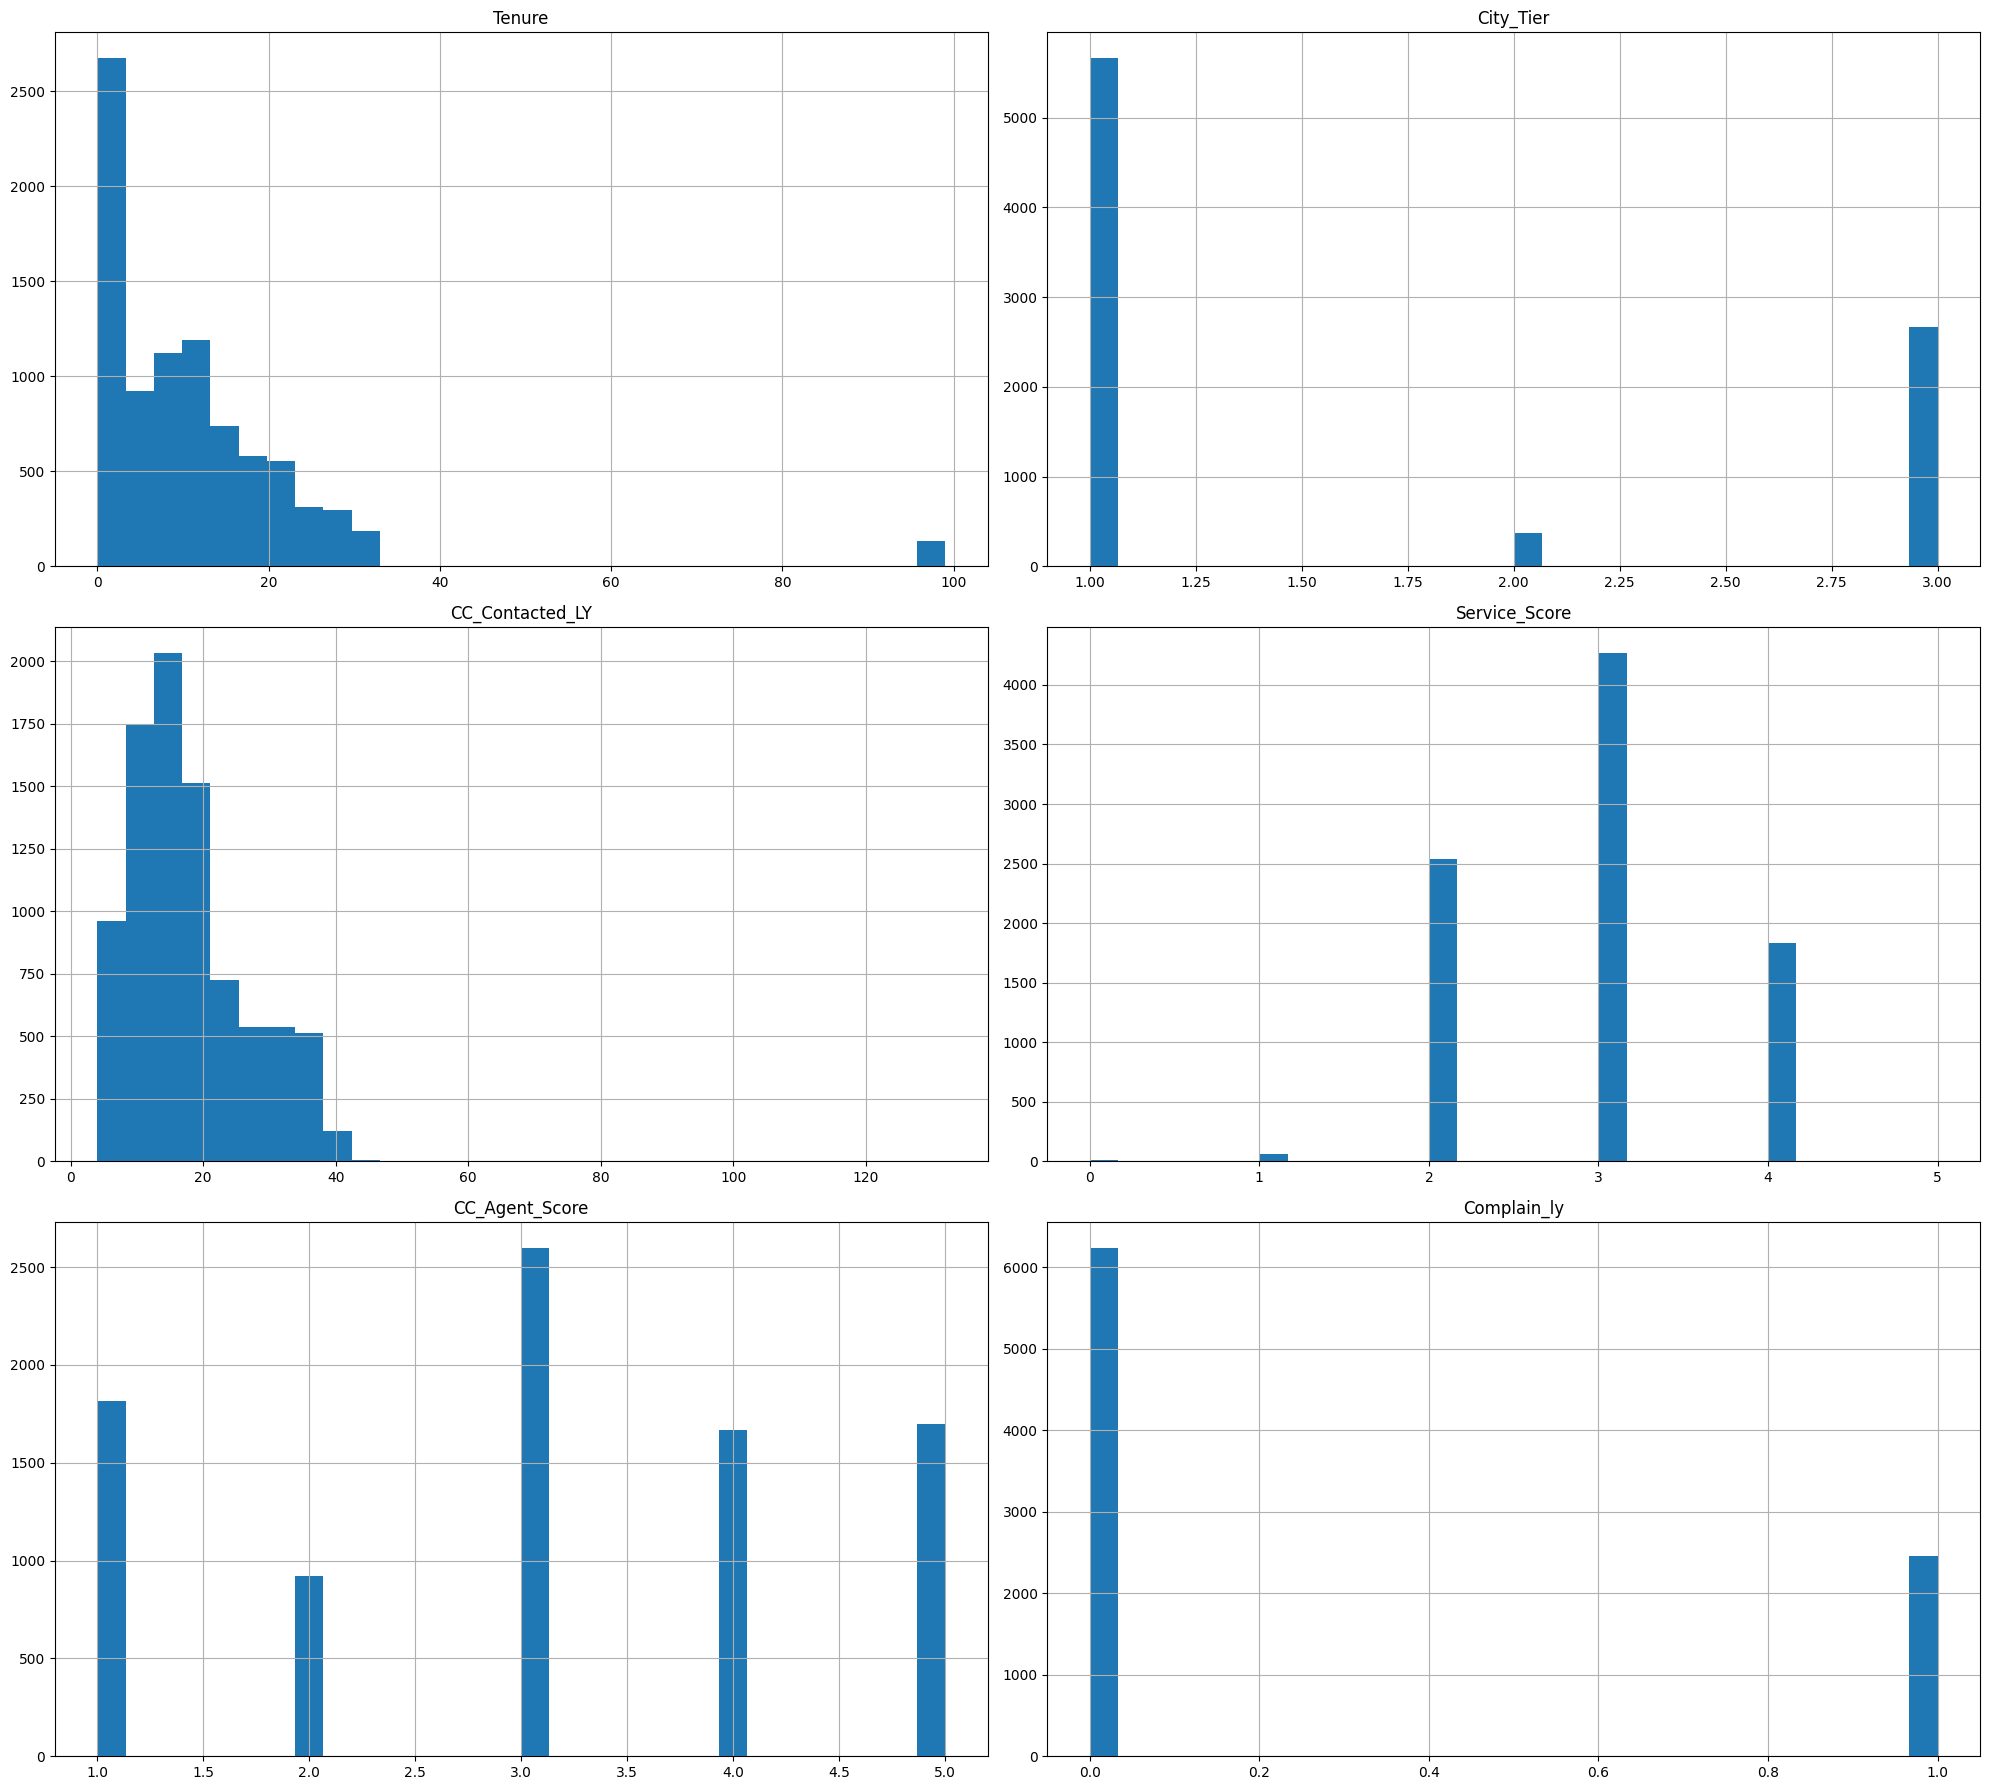

In [ ]:
import matplotlib.pyplot as plt

pdf.hist(figsize=(20,18), bins=30)
plt.tight_layout()
plt.show()

In [ ]:
len(df.columns)

18

In [ ]:
df.printSchema()

root
 |-- Churn: integer (nullable = true)
 |-- Tenure: integer (nullable = true)
 |-- City_Tier: integer (nullable = true)
 |-- CC_Contacted_LY: integer (nullable = true)
 |-- Payment: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Service_Score: integer (nullable = true)
 |-- Account_user_count: string (nullable = true)
 |-- account_segment: string (nullable = true)
 |-- CC_Agent_Score: integer (nullable = true)
 |-- Marital_Status: string (nullable = true)
 |-- rev_per_month: string (nullable = true)
 |-- Complain_ly: integer (nullable = true)
 |-- rev_growth_yoy: string (nullable = true)
 |-- coupon_used_for_payment: string (nullable = true)
 |-- Day_Since_CC_connect: string (nullable = true)
 |-- cashback: string (nullable = true)
 |-- Login_device: string (nullable = true)



### Scaling

In [ ]:
num_cols = [
 'Tenure',
 'City_Tier',
 'CC_Contacted_LY',
 'Service_Score',
 'CC_Agent_Score',
 'Complain_ly']

In [ ]:
## Assemble numerical columns into a vector

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F

assembler = VectorAssembler(
    inputCols=num_cols,
    outputCol="num_features"
)

df_vec = assembler.transform(df)

In [ ]:
len(df_vec.columns)

19

In [ ]:
## Apply Z-score scaling (StandardScaler)

from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="num_features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_vec)
df_scaled_vec = scaler_model.transform(df_vec)

In [ ]:
len(df_scaled_vec.columns)

20

In [ ]:
df_scaled_vec.printSchema()

root
 |-- Churn: integer (nullable = true)
 |-- Tenure: integer (nullable = true)
 |-- City_Tier: integer (nullable = true)
 |-- CC_Contacted_LY: integer (nullable = true)
 |-- Payment: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Service_Score: integer (nullable = true)
 |-- Account_user_count: string (nullable = true)
 |-- account_segment: string (nullable = true)
 |-- CC_Agent_Score: integer (nullable = true)
 |-- Marital_Status: string (nullable = true)
 |-- rev_per_month: string (nullable = true)
 |-- Complain_ly: integer (nullable = true)
 |-- rev_growth_yoy: string (nullable = true)
 |-- coupon_used_for_payment: string (nullable = true)
 |-- Day_Since_CC_connect: string (nullable = true)
 |-- cashback: string (nullable = true)
 |-- Login_device: string (nullable = true)
 |-- num_features: vector (nullable = true)
 |-- scaled_features: vector (nullable = true)



In [ ]:
## Convert vector back to individual columns (KEY STEP)

from pyspark.ml.functions import vector_to_array

df_scaled_arr = df_scaled_vec.withColumn(
    "scaled_array",
    vector_to_array("scaled_features")
)

In [ ]:
## Add scaled columns back (Spark equivalent of concat)

for i, col in enumerate(num_cols):
    df_scaled_arr = df_scaled_arr.withColumn(
        f"{col}_scaled",
        F.col("scaled_array")[i]
    )

In [ ]:
len(df_scaled_arr.columns)

27

In [ ]:
df_scaled_arr.printSchema()

root
 |-- Churn: integer (nullable = true)
 |-- Tenure: integer (nullable = true)
 |-- City_Tier: integer (nullable = true)
 |-- CC_Contacted_LY: integer (nullable = true)
 |-- Payment: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Service_Score: integer (nullable = true)
 |-- Account_user_count: string (nullable = true)
 |-- account_segment: string (nullable = true)
 |-- CC_Agent_Score: integer (nullable = true)
 |-- Marital_Status: string (nullable = true)
 |-- rev_per_month: string (nullable = true)
 |-- Complain_ly: integer (nullable = true)
 |-- rev_growth_yoy: string (nullable = true)
 |-- coupon_used_for_payment: string (nullable = true)
 |-- Day_Since_CC_connect: string (nullable = true)
 |-- cashback: string (nullable = true)
 |-- Login_device: string (nullable = true)
 |-- num_features: vector (nullable = true)
 |-- scaled_features: vector (nullable = true)
 |-- scaled_array: array (nullable = false)
 |    |-- element: double (containsNull = false)
 |-- 

In [ ]:
df_scaled = df_scaled_arr.drop('Tenure', 'City_Tier', 'CC_Contacted_LY', 'Service_Score', 'CC_Agent_Score', 'Complain_ly', 'num_features' , 'scaled_features', 'scaled_array')

In [ ]:
len(df_scaled.columns)

18

In [ ]:
df_scaled.printSchema()

root
 |-- Churn: integer (nullable = true)
 |-- Payment: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Account_user_count: string (nullable = true)
 |-- account_segment: string (nullable = true)
 |-- Marital_Status: string (nullable = true)
 |-- rev_per_month: string (nullable = true)
 |-- rev_growth_yoy: string (nullable = true)
 |-- coupon_used_for_payment: string (nullable = true)
 |-- Day_Since_CC_connect: string (nullable = true)
 |-- cashback: string (nullable = true)
 |-- Login_device: string (nullable = true)
 |-- Tenure_scaled: double (nullable = true)
 |-- City_Tier_scaled: double (nullable = true)
 |-- CC_Contacted_LY_scaled: double (nullable = true)
 |-- Service_Score_scaled: double (nullable = true)
 |-- CC_Agent_Score_scaled: double (nullable = true)
 |-- Complain_ly_scaled: double (nullable = true)



### Data encoding

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

cat_cols1 = [c for c, t in df_scaled.dtypes if t == "string"]
cat_cols1

['Payment',
 'Gender',
 'Account_user_count',
 'account_segment',
 'Marital_Status',
 'rev_per_month',
 'rev_growth_yoy',
 'coupon_used_for_payment',
 'Day_Since_CC_connect',
 'cashback',
 'Login_device']

In [ ]:
cat_cols = ['Gender','Marital_Status','Login_device','Payment','account_segment']

In [ ]:
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in cat_cols
]

encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in cat_cols],
    outputCols=[f"{c}_ohe" for c in cat_cols],
    dropLast=True
)

pipeline = Pipeline(stages=indexers + [encoder])

df_ohe = pipeline.fit(df_scaled).transform(df_scaled)


In [ ]:
## creates a list of StringIndexer transformers, one per categorical column.

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in cat_cols
]

In [ ]:
## Converts indexed categorical columns → one-hot encoded vectors

encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in cat_cols],
    outputCols=[f"{c}_ohe" for c in cat_cols],
    dropLast=True
)